In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, Image, display
import time
from abc import ABC, abstractmethod

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable
from tqdm import tqdm

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Dataset - 3D Ellipsoid Snowman

2 Ellipsoids with center on same line (intersection of x=a, y=b)

In [30]:
def make_ellipsoid_snowman(n_points=2048, snowman_type=None, noise=0.01, min_center_x=-1, max_center_x=1, min_center_y=-1, max_center_y=1, min_center_z=0, max_center_z=3):
    # Create a snowman
    # Type 1 (arms): two ellipsoids + two cuboid on lower ellipsoid for arms
    # Type 2 (nose): two ellipsoids + one cuboid on upper ellipsoid for nose
    # Type 3 (triple): three ellipsoids
    def ellipsoid(center, axes, n_points):
        phi = np.random.uniform(0, 2 * np.pi, n_points)
        costheta = np.random.uniform(-1, 1, n_points)
        u = np.random.uniform(0, 1, n_points)

        theta = np.arccos(costheta)
        r = u ** (1/3)

        x = center[0] + axes[0] * r * np.sin(theta) * np.cos(phi)
        y = center[1] + axes[1] * r * np.sin(theta) * np.sin(phi)
        z = center[2] + axes[2] * r * np.cos(theta)

        return x, y, z

    def cuboid(center, axes, n_points):
        ux = np.random.uniform(-axes[0], axes[0], n_points)
        uy = np.random.uniform(-axes[1], axes[1], n_points)
        uz = np.random.uniform(-axes[2], axes[2], n_points)

        x = center[0] + ux
        y = center[1] + uy
        z = center[2] + uz

        return x, y, z

    # Define the centers and axes of the ellipsoids
    if snowman_type is None:
        snowman_type = np.random.choice(['arms', 'nose', 'triple'])
    
    assert snowman_type in ['arms', 'nose', 'triple'], "Invalid snowman type. Choose from 'arms', 'nose', or 'triple'."

    if snowman_type == 'arms':
        ellipse_points = n_points // 3
        arm_point1 = (n_points - 2 * ellipse_points) // 2
        arm_point2 = n_points - 2 * ellipse_points - arm_point1
    elif snowman_type == 'nose':
        ellipse_points = n_points // 3
        nose_points = n_points - 2 * ellipse_points
    elif snowman_type == 'triple':
        ellipse_points = n_points // 3
        third_ellipse_points = n_points - 2 * ellipse_points

    center_x = np.random.uniform(min_center_x, max_center_x)
    center_y = np.random.uniform(min_center_y, max_center_y)
    center_z1 = np.random.uniform(min_center_z, max_center_z)
    center_z2 = np.random.uniform(center_z1 + 0.5, max_center_z + 0.5)

    axes1 = np.random.uniform(0.5, 1.0, size=3)
    axes2 = np.random.uniform(0.3, 0.8, size=3)
    centers = [(center_x, center_y, center_z1), (center_x, center_y, center_z2)]
    axes = [axes1, axes2]

    points = []
    for center, axis in zip(centers, axes):
        x, y, z = ellipsoid(center, axis, ellipse_points)
        points.append(np.vstack((x, y, z)).T)

    if snowman_type == 'arms':
        xy = np.random.choice([0, 1])
        arm_length = np.random.uniform(0.5, 1.0)
        arm_width = np.random.uniform(0.1, 0.2)
        
        if xy == 0:
            arm_centers = [(center_x - axes1[0] - arm_length / 2, center_y, center_z1), (center_x + axes1[0] + arm_length / 2, center_y, center_z1)]
            arm_axes = (arm_length, arm_width, arm_width)
        else:
            arm_centers = [(center_x, center_y - axes1[1] - arm_length / 2, center_z1), (center_x, center_y + axes1[1] + arm_length / 2, center_z1)]
            arm_axes = (arm_width, arm_length, arm_width)

        x, y, z = cuboid(arm_centers[0], arm_axes, arm_point1)
        points.append(np.vstack((x, y, z)).T)

        x, y, z = cuboid(arm_centers[1], arm_axes, arm_point2)
        points.append(np.vstack((x, y, z)).T)

    elif snowman_type == 'nose':
        nwes = np.random.choice([0, 1, 2, 3])
        nose_length = np.random.uniform(0.3, 0.5)
        nose_width = np.random.uniform(0.1, 0.2)

        if nwes == 0:
            nose_axes = (nose_length, nose_width, nose_width)
            nose_center = (center_x + axes2[0] + nose_length / 2, center_y, center_z2)
        elif nwes == 1:
            nose_axes = (nose_length, nose_width, nose_width)
            nose_center = (center_x - axes2[0] - nose_length / 2, center_y, center_z2)
        elif nwes == 2:
            nose_axes = (nose_width, nose_length, nose_width)
            nose_center = (center_x, center_y + axes2[1] + nose_length / 2, center_z2)
        else:
            nose_axes = (nose_width, nose_length, nose_width)
            nose_center = (center_x, center_y - axes2[1] - nose_length / 2, center_z2)

        x, y, z = cuboid(nose_center, nose_axes, nose_points)
        points.append(np.vstack((x, y, z)).T)

    elif snowman_type == 'triple':
        center_z3 = np.random.uniform(center_z2 + 0.5, max_center_z + 1.0)
        axes3 = np.random.uniform(0.2, 0.6, size=3)
        centers.append((center_x, center_y, center_z3))
        axes.append(axes3)
        x, y, z = ellipsoid(centers[-1], axes[-1], third_ellipse_points)
        points.append(np.vstack((x, y, z)).T)

    snowman_points = np.vstack(points)
    snowman_points += noise * np.random.randn(*snowman_points.shape)  # Add noise
    return snowman_points

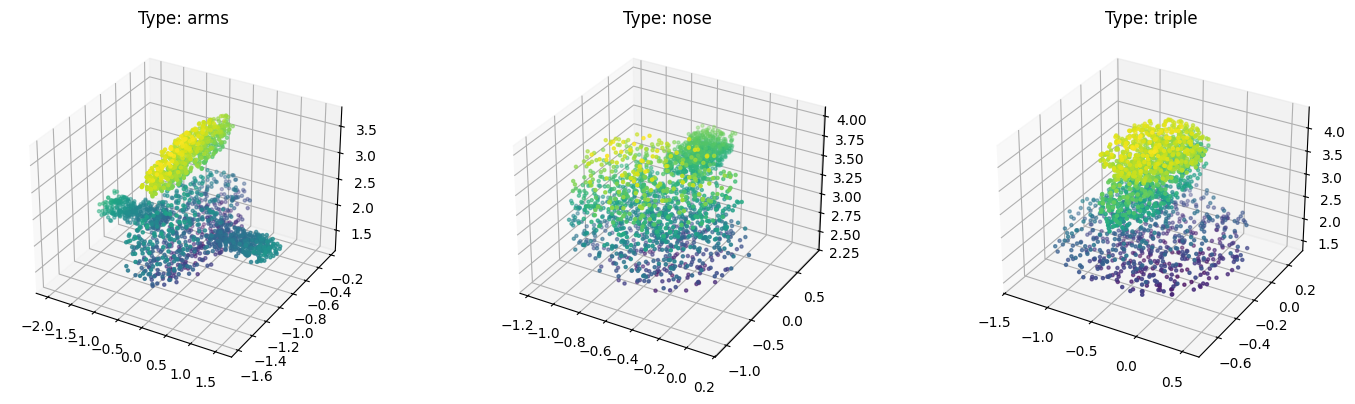

In [ ]:
fig = plt.figure(figsize=(15, 4))
types = ['arms', 'nose', 'triple']

# Plot three types of snowmen
for i, t in enumerate(types):
    pts = make_ellipsoid_snowman(snowman_type=t)
    depth = np.linalg.norm(pts, axis=1)

    ax = fig.add_subplot(1, 3, i + 1, projection='3d')
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=5, c=depth, cmap='viridis')
    ax.set_title(f'Type: {t}')

plt.tight_layout()
plt.show()

In [ ]:
def generate_snowmans(n_snowmans=1000, snowman_types = None, n_points_per_snowman=2048):
    snowmans = []
    if snowman_types is None:
        snowman_types = [None for i in range(n_snowmans)]
    for i in tqdm(range(n_snowmans), desc="Generating Snowmans"):
        snowman = make_ellipsoid_snowman(snowman_type=snowman_types[i], n_points=n_points_per_snowman)
        snowmans.append(snowman)
    return np.array(snowmans, dtype=np.float32)


def normalize_point_cloud_np(pc):
    # pc: (N, 3)
    center = np.mean(pc, axis=0, keepdims=True)
    pc = pc - center
    scale = np.max(np.linalg.norm(pc, axis=1))
    return pc / (scale + 1e-8)


def normalize_batch_point_clouds_np(batch_pc):
    # batch_pc: (B, N, 3)
    return np.stack([normalize_point_cloud_np(pc) for pc in batch_pc], axis=0).astype(np.float32)

In [49]:
n_snowmans = 2000
snowman_types = ['arms', 'nose', 'triple'] * (n_snowmans // 3) + ['arms'] * (n_snowmans % 3)

snowmans = generate_snowmans(n_snowmans=n_snowmans, snowman_types=snowman_types, n_points_per_snowman=2048)
snowmans = normalize_batch_point_clouds_np(snowmans)  # sample-wise center/scale normalization

snowmans_t = torch.from_numpy(snowmans).float()
trainset = torch.utils.data.TensorDataset(snowmans_t, snowmans_t)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True, drop_last=True)

Generating Snowmans: 100%|██████████| 2000/2000 [00:01<00:00, 1320.03it/s]


In [50]:
print(len(trainset))
print(len(trainloader))
print(trainset[0][0].shape)

2000
31
torch.Size([2048, 3])


## PointNet Autoencoder: without KL term, vanilla AE

### PointNet Encoder

In [51]:
class STNKd(nn.Module):
    # Spatial Transformer Network, a.k.a. T-Net for point clouds
    def __init__(self, k):
        super().__init__()
        self.k = k
        self.conv1 = nn.Sequential(nn.Conv1d(k, 64, 1), nn.BatchNorm1d(64))
        self.conv2 = nn.Sequential(nn.Conv1d(64, 128, 1), nn.BatchNorm1d(128))
        self.conv3 = nn.Sequential(nn.Conv1d(128, 1024, 1), nn.BatchNorm1d(1024))

        self.fc = nn.Sequential(
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, k * k)
        )
    
    def forward(self, x):
        # Input: (B, k, N)
        # Output: (B, k, k)
        batch_size = x.size(0)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = torch.max(x, 2)[0]  # (B, 1024)
        x = self.fc(x)  # (B, k*k)

        identity = Variable(torch.eye(self.k, device=x.device).view(1, self.k * self.k).repeat(batch_size, 1))

        x = x + identity  # Initialize as identity
        x = x.view(-1, self.k, self.k)  # (B, k, k)
        return x

In [54]:
class PointNetFeature(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_transform = STNKd(3)
        self.conv1 = nn.Sequential(nn.Conv1d(3, 64, 1), nn.BatchNorm1d(64))
        self.feature_transform = STNKd(64)
        self.conv2 = nn.Sequential(nn.Conv1d(64, 128, 1), nn.BatchNorm1d(128))
        self.conv3 = nn.Sequential(nn.Conv1d(128, 1024, 1), nn.BatchNorm1d(1024))

    def forward(self, x):
        # Input: (B, N, 3)
        # Output: (B, latent_dim)
        t3 = self.input_transform(x.transpose(1, 2))  # (B, 3, 3)
        x = torch.bmm(x, t3)  # (B, N, 3)
        x = F.relu(self.conv1(x.transpose(1, 2)))  # (B, 64, N)

        t64 = self.feature_transform(x)  # (B, 64, 64)
        x = torch.bmm(x.transpose(1, 2), t64).transpose(1, 2)  # (B, 64, N)
        x = F.relu(self.conv2(x))  # (B, 128, N)
        x = F.relu(self.conv3(x))  # (B, 1024, N)
        x = torch.max(x, 2)[0]  # (B, 1024)

        return x, t3, t64 # should regularize t3, t64 to orthogonal matrices

In [60]:
class PointNetEncoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.pointnet_feature = PointNetFeature()
        self.fc = nn.Sequential(
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )
    
    def forward(self, x):
        # Input: (B, N, 3)
        # Output: (B, latent_dim)
        features, t3, t64 = self.pointnet_feature(x)  # (B, 1024)
        x = self.fc(features)  # (B, latent_dim)

        return x, t3, t64 # should regularize t3, t64 to orthogonal matrices

In [55]:
def orthogonal_regularization(t, reg_weight=1e-3):
    # t: (B, k, k)
    batch_size, k, _ = t.size()
    identity = torch.eye(k, device=t.device).unsqueeze(0).repeat(batch_size, 1, 1)  # (B, k, k)
    t_transpose = t.transpose(1, 2)  # (B, k, k)
    product = torch.bmm(t, t_transpose)  # (B, k, k)

    mat_diff = (identity - product).reshape(batch_size, -1)  # (B, k*k)
    return reg_weight * torch.mean(torch.norm(mat_diff, dim=1))

In [61]:
test_encoder = PointNetEncoder(latent_dim=64).to(device)
test_input = torch.randn(2, 2048, 3).to(device)
test_output, t3, t64 = test_encoder(test_input)
print("Output shape:", test_output.shape)
print("t3 shape:", t3.shape)
print("t64 shape:", t64.shape)
print("Orthogonal reg t3:", orthogonal_regularization(t3).item())
print("Orthogonal reg t64:", orthogonal_regularization(t64).item())

Output shape: torch.Size([2, 64])
t3 shape: torch.Size([2, 3, 3])
t64 shape: torch.Size([2, 64, 64])
Orthogonal reg t3: 0.002060218481346965
Orthogonal reg t64: 0.12384071946144104


### Point Cloud Decoder

In [62]:
class PointDecoder(nn.Module):
    def __init__(self, latent_dim=64, n_points=2048):
        super().__init__()
        self.n_points = n_points

        self.fc_in = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU()
        )

        self.fc_res1 = nn.Sequential(
            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Linear(1024, 1024)
        )

        self.fc_res2 = nn.Sequential(
            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Linear(1024, 1024)
        )

        self.fc_out = nn.Sequential(
            nn.ReLU(),
            nn.Linear(1024, n_points * 3),
            nn.Tanh()  # normalized output range
        )

    def forward(self, x):
        # Input: (B, latent_dim)
        # Output: (B, N, 3)
        x = self.fc_in(x)
        x = x + self.fc_res1(x)
        x = x + self.fc_res2(x)
        x = self.fc_out(x)
        x = x.view(-1, self.n_points, 3)
        return x

In [63]:
test_decoder = PointDecoder(latent_dim=64, n_points=2048).to(device)
test_latent = torch.randn(2, 64).to(device)
test_decoded = test_decoder(test_latent)
print("Decoded shape:", test_decoded.shape)

Decoded shape: torch.Size([2, 2048, 3])


### PointNet Autoencoder

In [64]:
def chamfer_distance(points1, points2):
    # points1, points2: (B, N, 3)
    dist = torch.cdist(points1, points2, p=2) ** 2  # squared euclidean
    cd1 = torch.min(dist, dim=2)[0].mean(dim=1)
    cd2 = torch.min(dist, dim=1)[0].mean(dim=1)
    return (cd1 + cd2).mean()

In [65]:
class AEInterface(nn.Module, ABC):
    """Common interface for Autoencoders / Variational Autoencoders."""
    def __init__(self):
        super().__init__()

    @abstractmethod
    def encode(self, x):
        # Returns latent representation (or tuple/dict for VAE variants)
        raise NotImplementedError

    @abstractmethod
    def decode(self, latent):
        # Decodes latent to point cloud
        raise NotImplementedError

    @abstractmethod
    def reconstruct(self, x):
        # End-to-end reconstruction only
        raise NotImplementedError

    @abstractmethod
    def loss_forward(self, x, **kwargs):
        # Computes training loss (e.g., CD + regularizers [+ KL for VAE])
        raise NotImplementedError

    def forward(self, x):
        # Keep forward behavior consistent for inference/visualization
        return self.reconstruct(x)

In [66]:
class PointCloudAutoencoder(AEInterface):
    def __init__(self, latent_dim=64, n_points=2048, reg_weight=1e-3):
        super().__init__()
        self.encoder = PointNetEncoder(latent_dim=latent_dim)
        self.decoder = PointDecoder(latent_dim=latent_dim, n_points=n_points)
        self.reg_weight = reg_weight

    def encode(self, x):
        latent, _, _ = self.encoder(x)
        return latent

    def decode(self, latent):
        return self.decoder(latent)

    def reconstruct(self, x):
        latent, _, _ = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed

    def forward_with_aux(self, x):
        # Optional: expose transform matrices for regularization/debugging
        latent, t3, t64 = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed, t3, t64

    def loss_forward(self, x):
        reconstructed, t3, t64 = self.forward_with_aux(x)
        cd_loss = chamfer_distance(reconstructed, x)
        ortho_loss = orthogonal_regularization(t3, reg_weight=self.reg_weight) + orthogonal_regularization(t64, reg_weight=self.reg_weight)
        return cd_loss + ortho_loss

In [67]:
def train_PAE(pae, dataloader, n_epochs=120, lr=3e-4, weight_decay=1e-4):
    pae.train()

    optimizer = optim.AdamW(
        list(pae.parameters()),
        lr=lr,
        weight_decay=weight_decay
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=1e-5)

    losses = []
    for epoch in range(n_epochs):
        total_loss = 0.0
        for batch_idx, (data, _) in enumerate(dataloader):
            data = data.to(device).float()  # (B, N, 3)
            optimizer.zero_grad()

            loss = pae.loss_forward(data)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(list(pae.parameters()), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()

        scheduler.step()
        avg_loss = total_loss / len(dataloader)
        losses.append(avg_loss)
        current_lr = scheduler.get_last_lr()[0]
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.6f}, LR: {current_lr:.6e}")

    return losses

Epoch 1/40, Loss: 0.064460, LR: 2.995530e-04
Epoch 2/40, Loss: 0.015599, LR: 2.982148e-04
Epoch 3/40, Loss: 0.011929, LR: 2.959936e-04
Epoch 4/40, Loss: 0.010002, LR: 2.929032e-04
Epoch 5/40, Loss: 0.008730, LR: 2.889625e-04
Epoch 6/40, Loss: 0.007959, LR: 2.841959e-04
Epoch 7/40, Loss: 0.007121, LR: 2.786328e-04
Epoch 8/40, Loss: 0.006681, LR: 2.723075e-04
Epoch 9/40, Loss: 0.006037, LR: 2.652589e-04
Epoch 10/40, Loss: 0.005775, LR: 2.575305e-04
Epoch 11/40, Loss: 0.005174, LR: 2.491700e-04
Epoch 12/40, Loss: 0.005174, LR: 2.402289e-04
Epoch 13/40, Loss: 0.004894, LR: 2.307623e-04
Epoch 14/40, Loss: 0.004729, LR: 2.208286e-04
Epoch 15/40, Loss: 0.004627, LR: 2.104891e-04
Epoch 16/40, Loss: 0.004412, LR: 1.998075e-04
Epoch 17/40, Loss: 0.004293, LR: 1.888496e-04
Epoch 18/40, Loss: 0.004279, LR: 1.776830e-04
Epoch 19/40, Loss: 0.004063, LR: 1.663766e-04
Epoch 20/40, Loss: 0.004030, LR: 1.550000e-04
Epoch 21/40, Loss: 0.004046, LR: 1.436234e-04
Epoch 22/40, Loss: 0.003935, LR: 1.323170e-

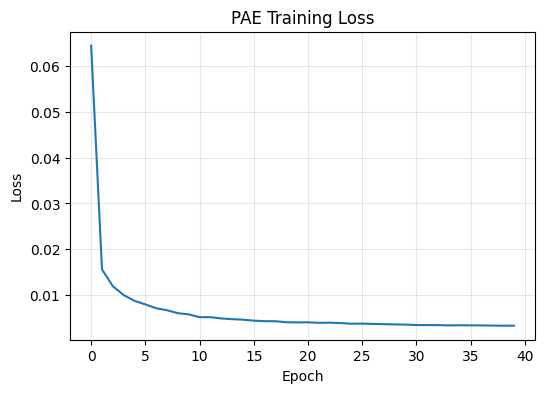

In [71]:
epochs = 40

ldim = 64
PAE = PointCloudAutoencoder(latent_dim=ldim, n_points=2048).to(device)

losses = train_PAE(PAE, trainloader, n_epochs=epochs, lr=3e-4, weight_decay=1e-4)

plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.title("PAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.show()

In [72]:
def reconstruct_and_visualize(AE, data):
    AE.eval()
    with torch.no_grad():
        data = data.to(device).float().unsqueeze(0)  # (1, N, 3)
        reconstructed = AE.reconstruct(data).squeeze(0).cpu().numpy()  # (N, 3)

    original = data.squeeze(0).cpu().numpy()

    fig = plt.figure(figsize=(12, 6))
    ax1 = fig.add_subplot(121, projection='3d')
    depth = np.linalg.norm(original, axis=1)
    ax1.scatter(original[:, 0], original[:, 1], original[:, 2], s=5, c=depth, cmap='viridis')
    ax1.set_title('Original Point Cloud')

    ax2 = fig.add_subplot(122, projection='3d')
    depth_recon = np.linalg.norm(reconstructed, axis=1)
    ax2.scatter(reconstructed[:, 0], reconstructed[:, 1], reconstructed[:, 2], s=5, c=depth_recon, cmap='viridis')
    ax2.set_title('Reconstructed Point Cloud')
    plt.show()

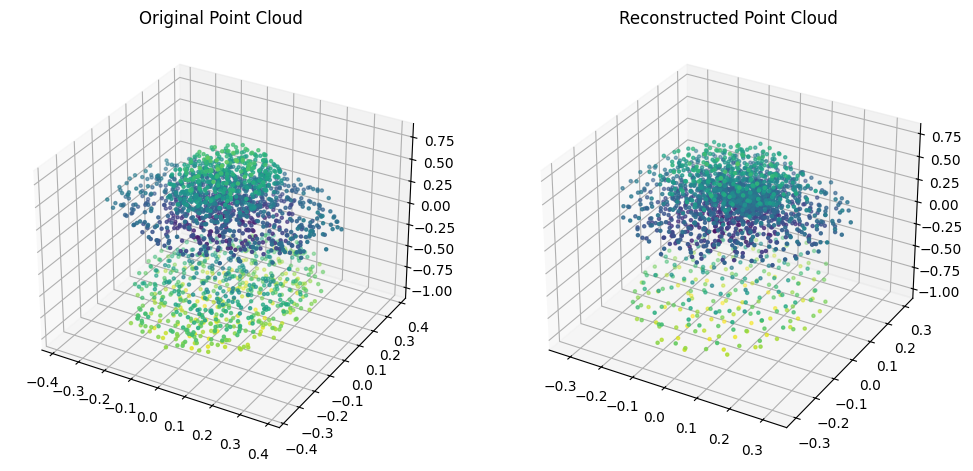

In [77]:
reconstruct_and_visualize(PAE, torch.tensor(normalize_point_cloud_np(make_ellipsoid_snowman())))

In [84]:
def latent_plot(AE, dataloader, n_batches=5, dim0=0, dim1=1):
    plt.figure(figsize=(6, 4))
    AE.eval()
    with torch.no_grad():
        for batch_idx, (data, _) in enumerate(dataloader):
            if batch_idx >= n_batches:
                break

            data = data.to(device).float()  # (B, N, 3)
            latent, _, _ = AE.encoder(data)  # (B, latent_dim)
            latent = latent.cpu().numpy()
            plt.scatter(latent[:, dim0], latent[:, dim1], s=10, alpha=0.5)
    plt.title(f'Latent Space (Dim {dim0} vs Dim {dim1})')
    plt.xlabel(f'Latent Dim {dim0}')
    plt.ylabel(f'Latent Dim {dim1}')
    plt.grid(True, alpha=0.3)
    plt.show()

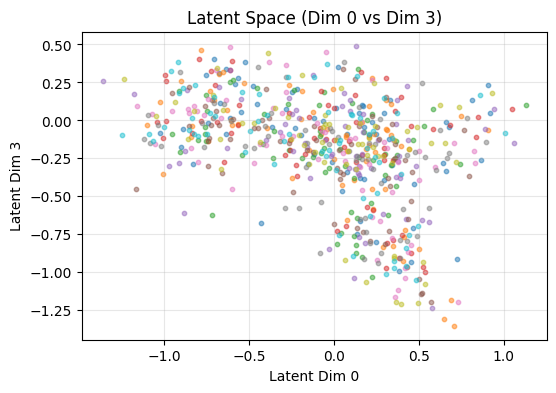

In [ ]:
n_batches = 12
dim0 = 0
dim1 = 3
latent_plot(PAE, trainloader, n_batches=n_batches, dim0=dim0, dim1=dim1)

In [97]:
def latent_interpolation(AE, latent_dim_idx=0, input_latent=None, min=-1.0, max=1.0, steps=10):
    AE.eval()
    with torch.no_grad():
        latent_vectors = []
        for alpha in np.linspace(min, max, steps):
            if input_latent is not None:
                latent = input_latent.clone().detach()
                if latent.dim() == 1:
                    latent = latent.unsqueeze(0)  # (D,) -> (1, D)
                latent = latent.to(device).float()
            else:
                latent = torch.randn(1, AE.decoder.fc_in[0].in_features, device=device)

            latent[0, latent_dim_idx] = float(alpha)
            latent_vectors.append(latent)

        latent_vectors = torch.cat(latent_vectors, dim=0)  # (steps, latent_dim)
        reconstructed_points = AE.decode(latent_vectors)  # (steps, N, 3)

    fig = plt.figure(figsize=(12, 6))
    for i in range(steps):
        ax = fig.add_subplot(2, steps // 2, i + 1, projection='3d')
        depth = np.linalg.norm(reconstructed_points[i].cpu().numpy(), axis=1)
        ax.scatter(
            reconstructed_points[i][:, 0].cpu(),
            reconstructed_points[i][:, 1].cpu(),
            reconstructed_points[i][:, 2].cpu(),
            s=5, c=depth, cmap='viridis'
        )
        ax.set_title(f'Alpha: {np.linspace(min, max, steps)[i]:.2f}')
    plt.tight_layout()
    plt.show()

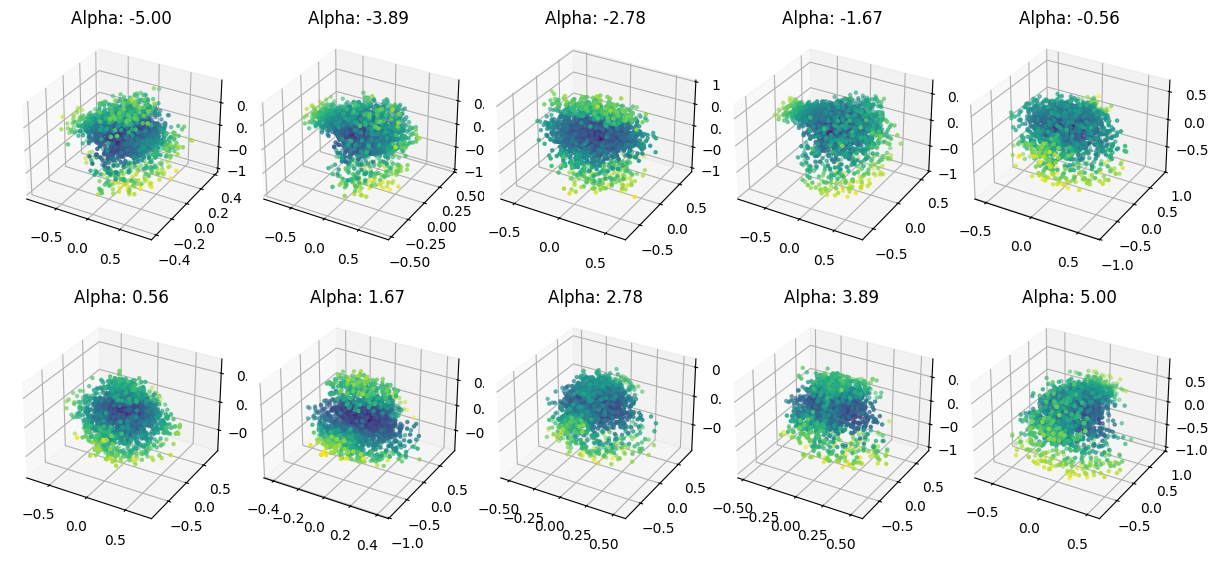

In [ ]:
latent = None
idx = 0
latent_interpolation(PAE, latent_dim_idx=idx, input_latent=latent, min=-5.0, max=5.0, steps=10)

In [117]:
def input_transform_visualization(AE, data):
    AE.eval()
    with torch.no_grad():
        data = data.to(device).float().unsqueeze(0)  # (1, N, 3)
        _, t3, _ = AE.encoder(data)  # (1, 3, 3)
        transformed = torch.bmm(data, t3).squeeze(0).cpu().numpy()  # (N, 3)

    original = data.squeeze(0).cpu().numpy()

    fig = plt.figure(figsize=(12, 6))
    ax1 = fig.add_subplot(121, projection='3d')
    depth = np.linalg.norm(original, axis=1)
    ax1.scatter(original[:, 0], original[:, 1], original[:, 2], s=5, c=depth, cmap='viridis')
    ax1.set_title('Original Point Cloud')

    ax2 = fig.add_subplot(122, projection='3d')
    depth_transformed = np.linalg.norm(transformed, axis=1)
    ax2.scatter(transformed[:, 0], transformed[:, 1], transformed[:, 2], s=5, c=depth_transformed, cmap='viridis')
    ax2.set_title('Transformed Point Cloud (Input T-Net)')
    plt.show()

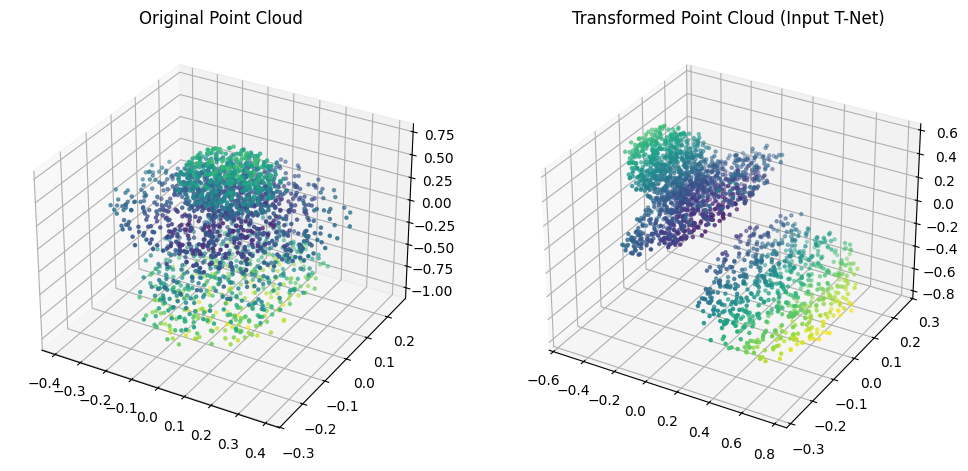

In [128]:
input_transform_visualization(PAE, torch.tensor(normalize_point_cloud_np(make_ellipsoid_snowman())))

## PointNet VAE

Naive Approach: Chamfer Distance + KL Div

### Variational PointNet Encoder

In [101]:
class PointNetVarEncoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.pointnet_feature = PointNetFeature()
        self.fc_mu = nn.Sequential(
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )
        self.fc_logvar = nn.Sequential(
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )

    def forward(self, x):
        features, t3, t64 = self.pointnet_feature(x)  # (B, 1024)
        mu = self.fc_mu(features)  # (B, latent_dim)
        logvar = self.fc_logvar(features)  # (B, latent_dim)
        return mu, logvar, t3, t64

In [102]:
test_var_encoder = PointNetVarEncoder(latent_dim=64).to(device)
test_mu, test_logvar, t3, t64 = test_var_encoder(test_input)
print("Mu shape:", test_mu.shape)
print("LogVar shape:", test_logvar.shape)

Mu shape: torch.Size([2, 64])
LogVar shape: torch.Size([2, 64])


### PointNet VAE

In [103]:
class PointCloudVAE(AEInterface):
    def __init__(self, latent_dim=64, n_points=2048, reg_weight=1e-3, kl_weight=1e-2):
        super().__init__()
        self.encoder = PointNetVarEncoder(latent_dim=latent_dim)
        self.decoder = PointDecoder(latent_dim=latent_dim, n_points=n_points)
        self.reg_weight = reg_weight
        self.kl_weight = kl_weight  # KL divergence weight

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def encode(self, x):
        mu, logvar, _, _ = self.encoder(x)
        return mu, logvar

    def decode(self, latent):
        return self.decoder(latent)

    def reconstruct(self, x):
        mu, logvar, _, _ = self.encoder(x)
        latent = self.reparameterize(mu, logvar)
        reconstructed = self.decoder(latent)
        return reconstructed

    def forward_with_aux(self, x):
        mu, logvar, t3, t64 = self.encoder(x)
        latent = self.reparameterize(mu, logvar)
        reconstructed = self.decoder(latent)
        return reconstructed, mu, logvar, t3, t64

    def loss_forward(self, x):
        reconstructed, mu, logvar, t3, t64 = self.forward_with_aux(x)
        cd_loss = chamfer_distance(reconstructed, x)
        ortho_loss = orthogonal_regularization(t3, reg_weight=self.reg_weight) + orthogonal_regularization(t64, reg_weight=self.reg_weight)
        kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        return cd_loss + ortho_loss + self.kl_weight * kl_loss

In [129]:
ldim = 64
epochs = 80

PVAE = PointCloudVAE(latent_dim=ldim, n_points=2048, kl_weight=1e-3).to(device)
vae_losses = train_PAE(PVAE, trainloader, n_epochs=epochs, lr=3e-4, weight_decay=1e-4)

Epoch 1/80, Loss: 0.052000, LR: 2.998882e-04
Epoch 2/80, Loss: 0.018288, LR: 2.995530e-04
Epoch 3/80, Loss: 0.013935, LR: 2.989949e-04
Epoch 4/80, Loss: 0.011684, LR: 2.982148e-04
Epoch 5/80, Loss: 0.011090, LR: 2.972139e-04
Epoch 6/80, Loss: 0.009255, LR: 2.959936e-04
Epoch 7/80, Loss: 0.008354, LR: 2.945560e-04
Epoch 8/80, Loss: 0.007804, LR: 2.929032e-04
Epoch 9/80, Loss: 0.007505, LR: 2.910377e-04
Epoch 10/80, Loss: 0.006765, LR: 2.889625e-04
Epoch 11/80, Loss: 0.006717, LR: 2.866808e-04
Epoch 12/80, Loss: 0.006163, LR: 2.841959e-04
Epoch 13/80, Loss: 0.005875, LR: 2.815119e-04
Epoch 14/80, Loss: 0.005792, LR: 2.786328e-04
Epoch 15/80, Loss: 0.005644, LR: 2.755631e-04
Epoch 16/80, Loss: 0.005475, LR: 2.723075e-04
Epoch 17/80, Loss: 0.005197, LR: 2.688710e-04
Epoch 18/80, Loss: 0.005124, LR: 2.652589e-04
Epoch 19/80, Loss: 0.004970, LR: 2.614768e-04
Epoch 20/80, Loss: 0.005057, LR: 2.575305e-04
Epoch 21/80, Loss: 0.004899, LR: 2.534261e-04
Epoch 22/80, Loss: 0.004825, LR: 2.491700e-

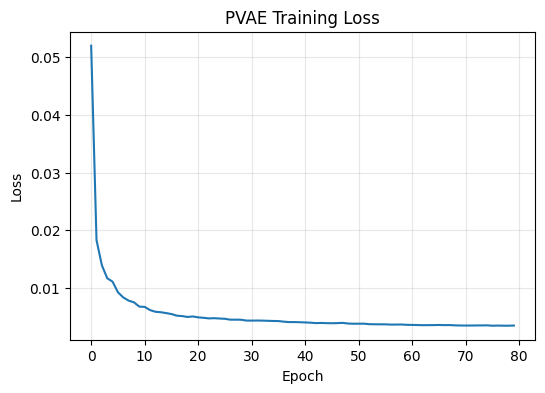

In [130]:
plt.figure(figsize=(6, 4))
plt.plot(vae_losses)
plt.title("PVAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.show()

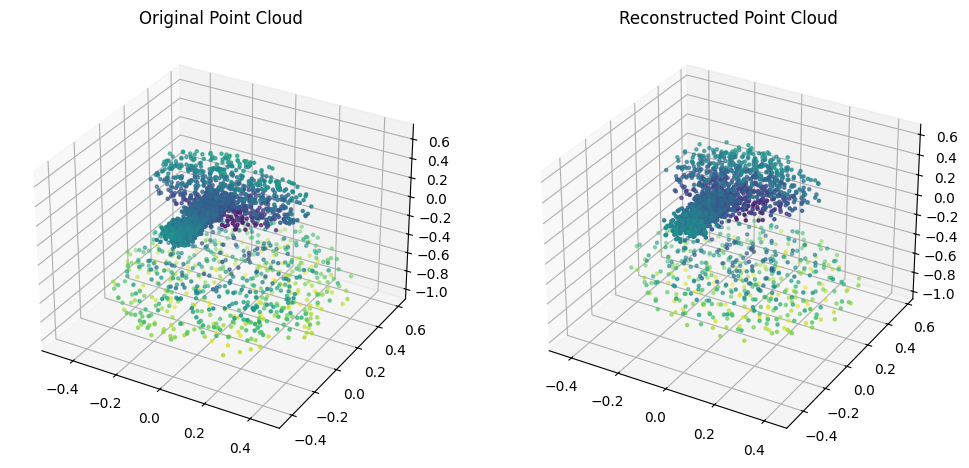

In [134]:
reconstruct_and_visualize(PVAE, torch.tensor(normalize_point_cloud_np(make_ellipsoid_snowman())).to(device).float())

In [ ]:
def vae_latent_plot(VAE, dataloader, n_batches=5, dim0=0, dim1=1):
    plt.figure(figsize=(6, 4))
    VAE.eval()
    with torch.no_grad():
        for batch_idx, (data, _) in enumerate(dataloader):
            if batch_idx >= n_batches:
                break

            data = data.to(device).float()  # (B, N, 3)
            latent, _, _, _ = VAE.encoder(data)  # (B, latent_dim)
            latent = latent.cpu().numpy()
            plt.scatter(latent[:, dim0], latent[:, dim1], s=10, alpha=0.5)
    plt.title(f'Latent Space (Dim {dim0} vs Dim {dim1})')
    plt.xlabel(f'Latent Dim {dim0}')
    plt.ylabel(f'Latent Dim {dim1}')
    plt.grid(True, alpha=0.3)
    plt.show()

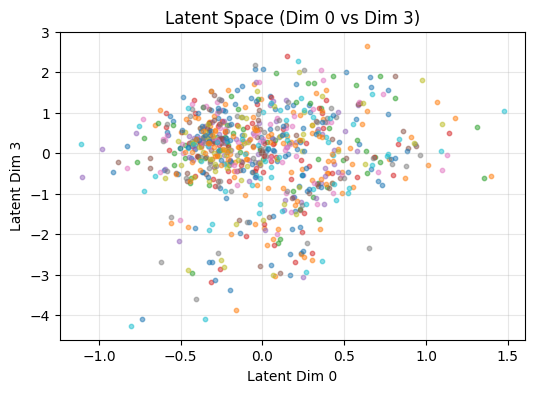

In [145]:
n_batches = 12
dim0 = 0
dim1 = 3
vae_latent_plot(PVAE, trainloader, n_batches=n_batches, dim0=dim0, dim1=dim1)

In [165]:
def sample_vae(VAE):
    VAE.eval()
    with torch.no_grad():
        latent = torch.randn(1, VAE.decoder.fc_in[0].in_features, device=device)
        sampled_points = VAE.decode(latent).squeeze(0).cpu().numpy()  # (N, 3)
    depth = np.linalg.norm(sampled_points, axis=1)
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(sampled_points[:, 0], sampled_points[:, 1], sampled_points[:, 2], s=5, c=depth, cmap='viridis')
    ax.set_title('Sampled Point Cloud from VAE')
    plt.show()

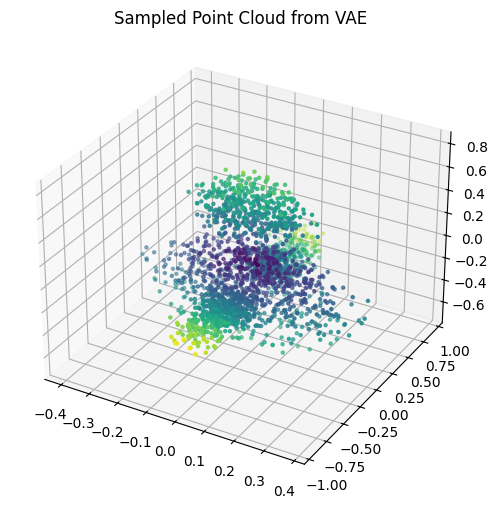

In [180]:
sample_vae(PVAE)

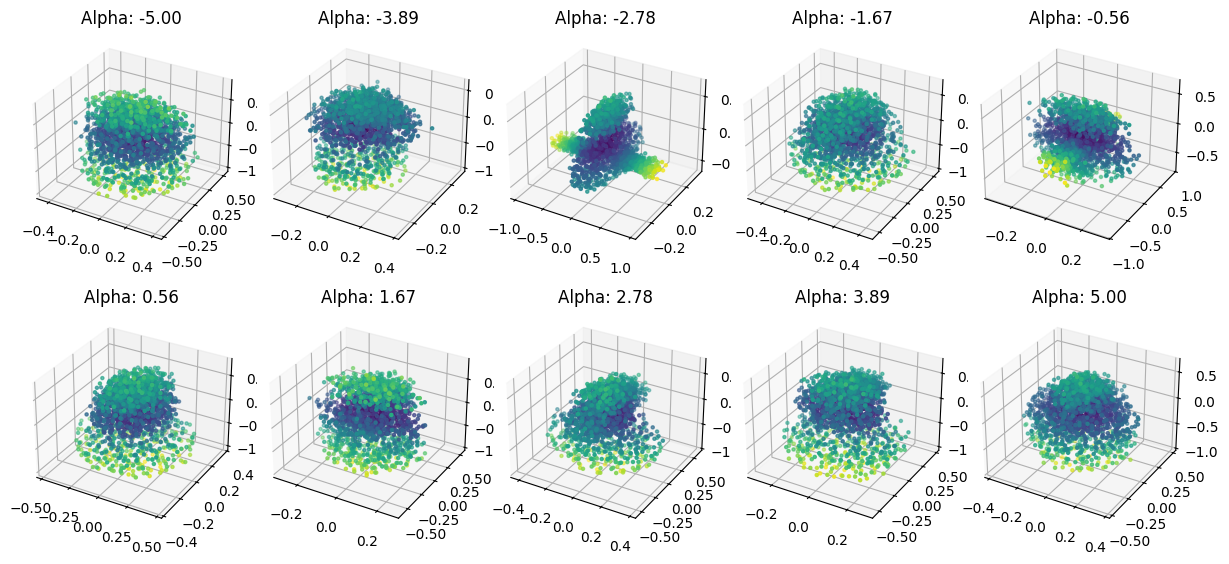

In [162]:
latent = None
idx = 0
latent_interpolation(PVAE, latent_dim_idx=idx, input_latent=latent, min=-5.0, max=5.0, steps=10)

## PointGMM

### PointGMM Decoder

In [260]:
class HierachicalSplitBlock(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, attn_dim, branching_factor=2):
        super().__init__()
        self.bf = branching_factor
        self.attn_dim = attn_dim
        self.out_dim = out_dim
        self.hidden_dim = hidden_dim

        self.fc = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.ReLU(),
            nn.Linear(256, hidden_dim * self.bf)
        )  # [..., in_dim] -> [..., hidden_dim * bf]

        # grouped 1x1 conv: each branch is processed independently
        self.Q = nn.Conv1d(hidden_dim * self.bf, attn_dim * self.bf, kernel_size=1, groups=self.bf, bias=True)
        self.K = nn.Conv1d(hidden_dim * self.bf, attn_dim * self.bf, kernel_size=1, groups=self.bf, bias=True)
        self.V = nn.Conv1d(hidden_dim * self.bf, out_dim * self.bf, kernel_size=1, groups=self.bf, bias=True)

        self.mu_head = nn.Linear(out_dim, 3)
        self.sigma_head = nn.Linear(out_dim, 3)
        self.logit_head = nn.Linear(out_dim, 1)

    def forward(self, x):
        # x: [B, Np, Din] or [B, Din]
        if x.dim() == 2:
            x = x.unsqueeze(1)
        B, Np, _ = x.shape

        h = self.fc(x)  # [B, Np, H*bf]
        h = h.reshape(B * Np, self.hidden_dim * self.bf, 1)  # [B*Np, H*bf, 1]

        # [B*Np, A*bf, 1] -> [B, Np, bf, A]
        q = self.Q(h).squeeze(-1).view(B, Np, self.bf, self.attn_dim)
        k = self.K(h).squeeze(-1).view(B, Np, self.bf, self.attn_dim)
        v = self.V(h).squeeze(-1).view(B, Np, self.bf, self.out_dim)

        # sibling attention inside each parent node
        attn_scores = torch.einsum('bnia,bnja->bnij', q, k) / (self.attn_dim ** 0.5)  # [B, Np, bf, bf]
        attn_weights = F.softmax(attn_scores, dim=-1)
        feat_child = torch.einsum('bnij,bnjo->bnio', attn_weights, v)  # [B, Np, bf, O]

        delta_mu = torch.tanh(self.mu_head(feat_child))                 # [B, Np, bf, 3]
        sigma = F.softplus(self.sigma_head(feat_child)) + 1e-6         # [B, Np, bf, 3]
        logit_local = self.logit_head(feat_child).squeeze(-1)          # [B, Np, bf] (raw logits)

        # flatten child nodes for next level
        feat_next = feat_child.reshape(B, Np * self.bf, self.out_dim)
        delta_mu = delta_mu.reshape(B, Np * self.bf, 3)
        sigma = sigma.reshape(B, Np * self.bf, 3)

        return feat_next, delta_mu, sigma, logit_local

In [261]:
test_hb = HierachicalSplitBlock(in_dim=64, hidden_dim=128, out_dim=32, attn_dim=16, branching_factor=4).to(device)
test_input = torch.randn(2, 64).to(device)
feat, delta_mu, sigma, log_logit = test_hb(test_input)
print("Feature shape:", feat.shape)          # [B, 4, 32]
print("Delta Mu shape:", delta_mu.shape)      # [B, 4, 3]
print("Sigma shape:", sigma.shape)            # [B, 4, 3]
print("Local Logit shape:", log_logit.shape)  # [B, 1, 4]
print("Prob sum per parent:", torch.softmax(log_logit, dim=-1).sum(dim=-1))

Feature shape: torch.Size([2, 4, 32])
Delta Mu shape: torch.Size([2, 4, 3])
Sigma shape: torch.Size([2, 4, 3])
Local Logit shape: torch.Size([2, 1, 4])
Prob sum per parent: tensor([[1.],
        [1.]], device='cuda:0', grad_fn=<SumBackward1>)


In [266]:
class PointGMMDecoder(nn.Module):
    def __init__(self, latent_dim=64, attn_dim=16, value_dim=32, branch_factor=2, level=3):
        super().__init__()
        self.branch_factor = branch_factor
        self.level = level
        self.n_branches = branch_factor ** level

        self.fc_in = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU()
        )

        self.mu_init = nn.Linear(1024, 3)  # root mean

        self.hbs = nn.ModuleList([
            HierachicalSplitBlock(
                in_dim=1024 if i == 0 else value_dim,
                hidden_dim=128,
                out_dim=value_dim,
                attn_dim=attn_dim,
                branching_factor=branch_factor
            ) for i in range(level)
        ])

    def forward(self, z):
        # Input: z [B, latent_dim]
        # Output: mu [B, K, 3], sigma [B, K, 3], logpi [B, K] (K = branch_factor^level)
        B = z.size(0)
        root_feat = self.fc_in(z)                 # [B, 1024]
        feat = root_feat.unsqueeze(1)             # [B, 1, 1024]

        mu = self.mu_init(root_feat).unsqueeze(1) # [B, 1, 3]
        sigma = torch.ones_like(mu) * 0.1         # [B, 1, 3]
        logpi = torch.zeros(B, 1, device=z.device) # [B, 1]

        levelwise_results = []

        for hb in self.hbs:
            # feat_next: [B, Np*bf, D], delta/sigma_rel: [B, Np*bf, 3], logit_local: [B, Np, bf]
            feat, delta_mu, sigma_rel, logit_local = hb(feat)

            Np = mu.size(1)
            bf = self.branch_factor

            parent_mu = mu.unsqueeze(2).expand(B, Np, bf, 3).reshape(B, Np * bf, 3)
            parent_sigma = sigma.unsqueeze(2).expand(B, Np, bf, 3).reshape(B, Np * bf, 3)

            mu = parent_mu + delta_mu
            sigma = parent_sigma * sigma_rel

            # accumulate mixture logits in log-space
            child_logpi = logpi.unsqueeze(-1) + F.log_softmax(logit_local, dim=-1)  # [B, Np, bf]
            logpi = child_logpi.reshape(B, Np * bf)

            levelwise_results.append((mu, sigma, logpi))

        return mu, sigma, logpi, levelwise_results

In [268]:
test_gmm_dec = PointGMMDecoder(latent_dim=64, attn_dim=16, value_dim=32, branch_factor=2, level=3).to(device)
test_z = torch.randn(2, 64).to(device)
mu, sigma, logpi, levelwise_results = test_gmm_dec(test_z)
print("GMM mu shape:", mu.shape)      # [B, 8, 3]
print("GMM sigma shape:", sigma.shape)# [B, 8, 3]
print("GMM logpi shape:", logpi.shape)# [B, 8]
print("Mix prob sum:", torch.softmax(logpi, dim=1).sum(dim=1))
print("Levelwise results:", [r[0].shape for r in levelwise_results])

GMM mu shape: torch.Size([2, 8, 3])
GMM sigma shape: torch.Size([2, 8, 3])
GMM logpi shape: torch.Size([2, 8])
Mix prob sum: tensor([1., 1.], device='cuda:0', grad_fn=<SumBackward1>)
Levelwise results: [torch.Size([2, 2, 3]), torch.Size([2, 4, 3]), torch.Size([2, 8, 3])]


### PointGMM VAE

In [275]:
class PointGMMVAE(AEInterface):
    def __init__(self, latent_dim=64, attn_dim=16, value_dim=32, branch_factor=2, level=3, reg_weight=1e-3, kl_weight=1e-2):
        super().__init__()
        self.encoder = PointNetVarEncoder(latent_dim=latent_dim)
        self.decoder = PointGMMDecoder(latent_dim=latent_dim, attn_dim=attn_dim, value_dim=value_dim, branch_factor=branch_factor, level=level)
        self.reg_weight = reg_weight
        self.kl_weight = kl_weight

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def encode(self, x):
        mu, logvar, _, _ = self.encoder(x)
        return mu, logvar

    def decode(self, latent):
        return self.decoder(latent)
    
    def gmm_loss(self, x, levelwise_results):
        # x: [B, N, 3]
        # levelwise_results: list of (mu [B, K, 3], sigma [B, K, 3], logpi [B, K]) for each level
        total_loss = 0.0
        for mu, sigma, logpi in levelwise_results:
            B, K, _ = mu.size()
            x_expanded = x.unsqueeze(2)  # [B, N, 1, 3]
            mu_expanded = mu.unsqueeze(1)  # [B, 1, K, 3]
            sigma_expanded = sigma.unsqueeze(1)  # [B, 1, K, 3]

            dist = torch.sum(((x_expanded - mu_expanded) / (sigma_expanded + 1e-6)) ** 2, dim=-1)  # [B, N, K]
            log_prob = -0.5 * dist + logpi.unsqueeze(1) - torch.sum(torch.log(sigma_expanded), dim=-1)  # [B, N, K]

            log_prob_max = torch.max(log_prob, dim=-1)[0]  # [B, N]
            log_prob_sum = log_prob_max + torch.log(torch.sum(torch.exp(log_prob - log_prob_max.unsqueeze(-1)), dim=-1))  # [B, N]
            total_loss += -torch.mean(log_prob_sum)

        return total_loss

    def gmm_sample(self, mu, sigma, logpi, n_points=2048):
        # mu, sigma: [B, K, 3], logpi: [B, K]
        B, K, _ = mu.size()
        pi = torch.softmax(logpi, dim=1)  # [B, K]
        categorical = torch.distributions.Categorical(pi)
        component_indices = categorical.sample((n_points,)).transpose(0, 1)  # [B, N]

        batch_indices = torch.arange(B, device=mu.device).unsqueeze(1).expand(B, component_indices.size(1))  # [B, N]
        selected_mu = mu[batch_indices, component_indices]  # [B, N, 3]
        selected_sigma = sigma[batch_indices, component_indices]  # [B, N, 3]

        eps = torch.randn_like(selected_sigma)
        sampled_points = selected_mu + eps * selected_sigma
        return sampled_points

    def reconstruct(self, x):
        mu, logvar, _, _ = self.encoder(x)
        latent = self.reparameterize(mu, logvar)
        decoded_mu, decoded_sigma, decoded_logpi, _ = self.decoder(latent)
        return self.gmm_sample(decoded_mu, decoded_sigma, decoded_logpi)
    
    def decoder_sample(self, latent, n_points=2048):
        decoded_mu, decoded_sigma, decoded_logpi, _ = self.decoder(latent)
        return self.gmm_sample(decoded_mu, decoded_sigma, decoded_logpi, n_points=n_points)

    def forward_with_aux(self, x):
        mu, logvar, t3, t64 = self.encoder(x)
        latent = self.reparameterize(mu, logvar)
        decoded_mu, decoded_sigma, decoded_logpi, levelwise_results = self.decoder(latent)
        return decoded_mu, levelwise_results, mu, logvar, t3, t64

    def loss_forward(self, x):
        decoded_mu, levelwise_results, mu, logvar, t3, t64 = self.forward_with_aux(x)

        gmm_loss = self.gmm_loss(x, levelwise_results)

        ortho_loss = orthogonal_regularization(t3) + orthogonal_regularization(t64)

        kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

        return gmm_loss + self.reg_weight * ortho_loss + self.kl_weight * kl_loss

In [276]:
test_gmm_vae = PointGMMVAE(latent_dim=64, attn_dim=16, value_dim=32, branch_factor=2, level=3).to(device)
test_input = torch.randn(2, 2048, 3).to(device)
loss = test_gmm_vae.loss_forward(test_input)
test_latent = torch.randn(2, 64).to(device)
sampled_points = test_gmm_vae.decoder_sample(test_latent, n_points=2048)
test_reconstructed = test_gmm_vae.reconstruct(test_input)
print("Reconstructed shape:", test_reconstructed.shape)
print("Sampled points shape:", sampled_points.shape)
print("GMM-VAE Loss:", loss.item())

Reconstructed shape: torch.Size([2, 2048, 3])
Sampled points shape: torch.Size([2, 2048, 3])
GMM-VAE Loss: 2636.556640625
